[House Prices - Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data) 🏠

# Imports

In [1]:
# Use this cell to regroup all your imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import set_config
set_config(display = 'diagram')

# Sklearn preprocessing
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, StandardScaler, RobustScaler

# Sklearn pipelines
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.pipeline import make_pipeline

# Sklearn model selection
from scipy import stats
from sklearn.metrics import make_scorer, mean_squared_error, mean_squared_log_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV, cross_validate


# models
from sklearn.ensemble import AdaBoostRegressor,GradientBoostingRegressor, StackingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge, LinearRegression, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor

In [2]:
data = pd.read_csv('https://wagon-public-datasets.s3.amazonaws.com/houses_train_raw.csv', index_col='Id')
data

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


In [3]:
data.isna().sum().sort_values().tail(10)

GarageQual        81
GarageFinish      81
GarageCond        81
GarageType        81
LotFrontage      259
FireplaceQu      690
Fence           1179
Alley           1369
MiscFeature     1406
PoolQC          1453
dtype: int64

In [4]:
data.isna().sum()[data.isna().sum() > 600].index

Index(['Alley', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature'], dtype='object')

In [5]:
data.duplicated().sum()

0

In [6]:
X = data.drop(columns=['SalePrice','Alley', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature'])
y = data.SalePrice

X.shape, y.shape

((1460, 74), (1460,))

# Preprocessing

Let's take a look at the number of numerical vs categorical features we have.

In [7]:
X.dtypes.value_counts()

object     38
int64      33
float64     3
dtype: int64

In [8]:
num_cols = X.select_dtypes(exclude='object').columns
cat_cols = X.select_dtypes(include='object').columns

## Numerical Preprocessing

### Simple preprocessing

In [9]:
preproc_num_simple = make_pipeline(
                    SimpleImputer(),
                    RobustScaler()
                    )
preproc_num_simple

Pipeline(steps=[('simpleimputer', SimpleImputer()),
                ('robustscaler', RobustScaler())])

Let's make sure it works

In [10]:
preproc_num_simple.fit_transform(X[num_cols])

array([[ 2.00000000e-01, -2.65787283e-01, -2.54076087e-01, ...,
         0.00000000e+00, -1.33333333e+00,  0.00000000e+00],
       [-6.00000000e-01,  5.23686402e-01,  3.00148221e-02, ...,
         0.00000000e+00, -3.33333333e-01, -5.00000000e-01],
       [ 2.00000000e-01, -1.07892546e-01,  4.37623518e-01, ...,
         0.00000000e+00,  1.00000000e+00,  0.00000000e+00],
       ...,
       [ 4.00000000e-01, -2.13155704e-01, -1.07831028e-01, ...,
         2.50000000e+03, -3.33333333e-01,  1.00000000e+00],
       [-6.00000000e-01, -1.07892546e-01,  5.89179842e-02, ...,
         0.00000000e+00, -6.66666667e-01,  1.00000000e+00],
       [-6.00000000e-01,  2.60528507e-01,  1.13265810e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

### More detailed preproc

Let's take a look at the distribution of all of the numerical features in X.

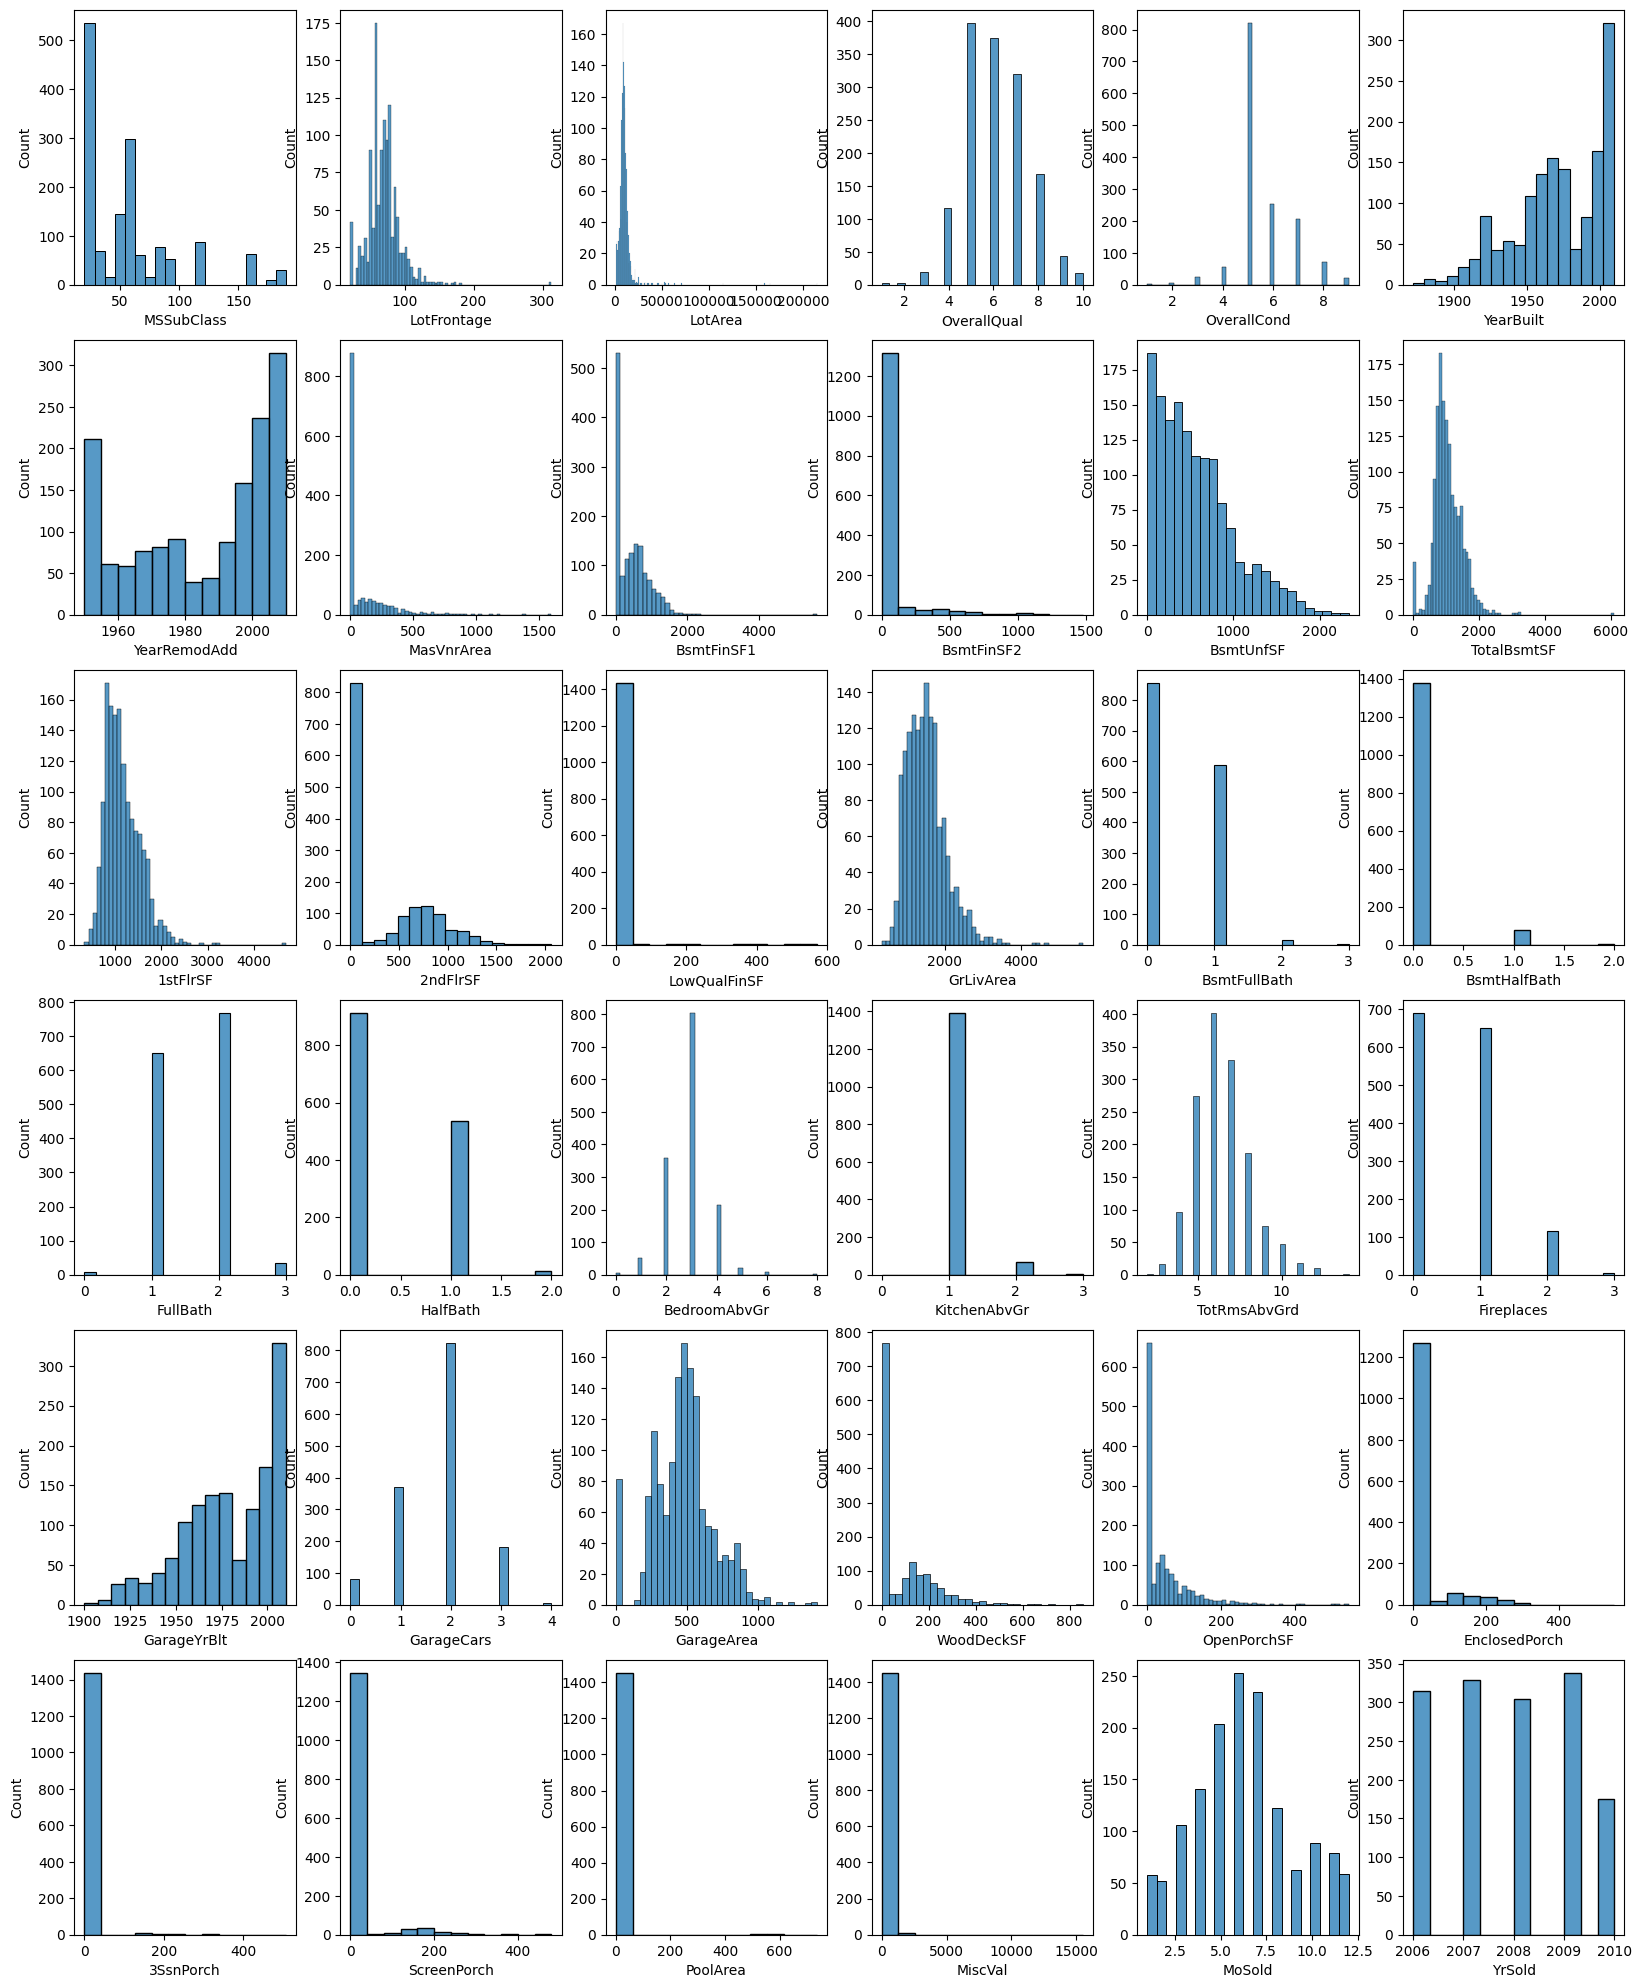

In [11]:
fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(20, 25))

for col, ax in zip(num_cols, axes.ravel()):
    sns.histplot(X[col], ax=ax)

In [12]:
robust_feat = ['MSSubClass', 'LotFrontage', 'LotArea',
       'YearBuilt', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF',   '2ndFlrSF', 'LowQualFinSF',
       'GarageYrBlt',  'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
        ]
standard_feat = ['OverallQual', 'OverallCond', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'BedroomAbvGr', 'TotRmsAbvGrd',
                'GarageCars', 'GarageArea', 'MoSold']
minmax_feat = ['YearRemodAdd', 'BsmtFullBath', 'BsmtHalfBath', 'YrSold', 'FullBath', 'HalfBath', 'KitchenAbvGr',  'Fireplaces',]

In [13]:
standard_transformer = make_pipeline(
                 KNNImputer(),
                StandardScaler()
                    )

minmax_transformer = make_pipeline(
                 KNNImputer(),
                MinMaxScaler()
                    )

robust_transformer = make_pipeline(
                 KNNImputer(),
                RobustScaler()
                    )

preproc_num_advanced = make_column_transformer(
                (standard_transformer, standard_feat),
                (minmax_transformer, minmax_feat),
                (robust_transformer, robust_feat),
                )
preproc_num_advanced

ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('knnimputer', KNNImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 ['OverallQual', 'OverallCond', 'TotalBsmtSF',
                                  '1stFlrSF', 'GrLivArea', 'BedroomAbvGr',
                                  'TotRmsAbvGrd', 'GarageCars', 'GarageArea',
                                  'MoSold']),
                                ('pipeline-2',
                                 Pipeline(steps=[('knnimputer', KNNImputer()),
                                                 ('minmaxscaler',
                                                  MinMaxScaler())...
                                  'HalfBath', 'KitchenAbvGr', 'Fireplaces']),
                                ('pipeline-3',
                                 Pipeline(steps=[('knnimputer', KNNImputer()),
                                                 ('robustscaler',
                                                  RobustScaler())]),
                                 ['MSSubClass', 'LotFrontage', 'LotArea',
                                  'YearBuilt', 'MasVnrArea', 'BsmtFinSF1',
                                  'BsmtFinSF2', 'BsmtUnfSF', '2ndFlrSF',
                                  'LowQualFinSF', 'GarageYrBlt', 'WoodDeckSF',
                                  'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
                                  'ScreenPorch', 'PoolArea', 'MiscVal'])])

In [14]:
preproc_num_advanced.fit_transform(X)

array([[ 6.51479243e-01, -5.17199807e-01, -4.59302541e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-7.18361143e-02,  2.17962776e+00,  4.66464916e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 6.51479243e-01, -5.17199807e-01, -3.13368755e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 6.51479243e-01,  3.07857028e+00,  2.15641221e-01, ...,
         0.00000000e+00,  0.00000000e+00,  2.50000000e+03],
       [-7.95151472e-01,  3.81742715e-01,  4.69052804e-02, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-7.95151472e-01,  3.81742715e-01,  4.52783624e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

## Categorical Preprocessing

### Simple cat preprocessing

In [15]:
len(cat_cols)

38

In [16]:
feat_categorical_nunique = X.select_dtypes(include='object').nunique()

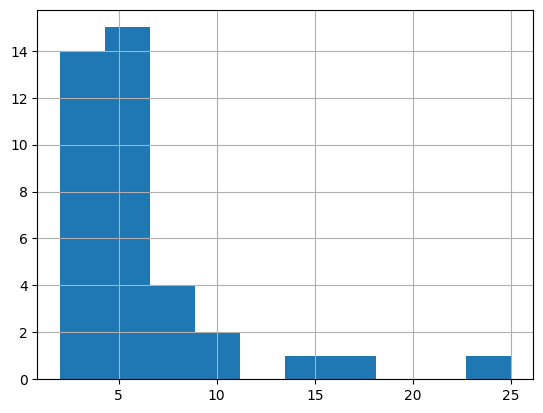

In [17]:
feat_categorical_nunique.hist();

In [18]:
feat_categorical_small = list(feat_categorical_nunique[feat_categorical_nunique < 7].index)

In [19]:
len(feat_categorical_small)

29

In [20]:
preproc_cat_simple = make_pipeline(
                    SimpleImputer(strategy='most_frequent'),
                    OneHotEncoder(handle_unknown='ignore'))
preproc_cat_simple

Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                ('onehotencoder', OneHotEncoder(handle_unknown='ignore'))])

In [21]:
preproc_cat_simple.fit_transform(X[feat_categorical_small])

<1460x129 sparse matrix of type '<class 'numpy.float64'>'
	with 42340 stored elements in Compressed Sparse Row format>

The reason why we chose not to one hot encode every single column is in order NOT to end up with 7000+ columns...

In [22]:
preproc_cat_simple.fit_transform(X)

<1460x7611 sparse matrix of type '<class 'numpy.float64'>'
	with 108040 stored elements in Compressed Sparse Row format>

### More detailed preproc

#### Ordinal Encoding

In [23]:
feat_ordinal_dict = {
    "BsmtCond": ['missing', 'Po', 'Fa', 'TA', 'Gd'],
    "BsmtExposure": ['missing', 'No', 'Mn', 'Av', 'Gd'],
    "BsmtFinType1": ['missing', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    "BsmtFinType2": ['missing', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    "BsmtQual": ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
    "Electrical": ['missing', 'Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr'],
    "ExterCond": ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    "ExterQual": ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
    "Functional": ['missing', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    "GarageCond": ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    "GarageFinish": ['missing', 'Unf', 'RFn', 'Fin'],
    "GarageQual": ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    "HeatingQC": ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    "KitchenQual": ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
    "LandContour": ['missing', 'Low', 'Bnk', 'HLS', 'Lvl'],
    "LandSlope": ['missing', 'Sev', 'Mod', 'Gtl'],
    "LotShape": ['missing', 'IR3', 'IR2', 'IR1', 'Reg'],
    "PavedDrive": ['missing', 'N', 'P', 'Y'],
}

In [24]:
feat_ordinal = sorted(feat_ordinal_dict.keys()) # sort alphabetically

In [25]:
feat_ordinal_values_sorted = [feat_ordinal_dict[i] for i in feat_ordinal]
feat_ordinal_values_sorted

[['missing', 'Po', 'Fa', 'TA', 'Gd'],
 ['missing', 'No', 'Mn', 'Av', 'Gd'],
 ['missing', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
 ['missing', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
 ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
 ['missing', 'Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr'],
 ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
 ['missing', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
 ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['missing', 'Unf', 'RFn', 'Fin'],
 ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
 ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
 ['missing', 'Low', 'Bnk', 'HLS', 'Lvl'],
 ['missing', 'Sev', 'Mod', 'Gtl'],
 ['missing', 'IR3', 'IR2', 'IR1', 'Reg'],
 ['missing', 'N', 'P', 'Y']]

In [26]:
encoder_ordinal = OrdinalEncoder(
    categories=feat_ordinal_values_sorted,
    dtype= np.int64,
    handle_unknown="use_encoded_value",
    unknown_value=-1 # Considers unknown values as worse than "missing"
)

In [27]:
preproc_ordinal = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="missing"),
    encoder_ordinal,
    MinMaxScaler()
)
preproc_ordinal

Pipeline(steps=[('simpleimputer',
                 SimpleImputer(fill_value='missing', strategy='constant')),
                ('ordinalencoder',
                 OrdinalEncoder(categories=[['missing', 'Po', 'Fa', 'TA', 'Gd'],
                                            ['missing', 'No', 'Mn', 'Av', 'Gd'],
                                            ['missing', 'Unf', 'LwQ', 'Rec',
                                             'BLQ', 'ALQ', 'GLQ'],
                                            ['missing', 'Unf', 'LwQ', 'Rec',
                                             'BLQ', 'ALQ', 'GLQ'],
                                            ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
                                            ['missing', 'Mix', 'FuseP...
                                            ['missing', 'Unf', 'RFn', 'Fin'],
                                            ['missing', 'Po', 'Fa', 'TA', 'Gd',
                                             'Ex'],
                                            ['missing', 'Po', 'Fa', 'TA', 'Gd',
                                             'Ex'],
                                            ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
                                            ['missing', 'Low', 'Bnk', 'HLS',
                                             'Lvl'],
                                            ['missing', 'Sev', 'Mod', 'Gtl'],
                                            ['missing', 'IR3', 'IR2', 'IR1',
                                             'Reg'],
                                            ['missing', 'N', 'P', 'Y']],
                                dtype=<class 'numpy.int64'>,
                                handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('minmaxscaler', MinMaxScaler())])

#### One hot encoder

In [28]:
feat_nom = list(set(cat_cols) - set(feat_ordinal))

In [29]:
preproc_nom = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

## Final Preprocessing Pipeline

In [30]:
preproc = make_column_transformer(
            (preproc_num_advanced, num_cols),
            (preproc_nom, feat_nom),
            (preproc_ordinal, feat_ordinal),
            remainder='drop'
                )
preproc

ColumnTransformer(transformers=[('columntransformer',
                                 ColumnTransformer(transformers=[('pipeline-1',
                                                                  Pipeline(steps=[('knnimputer',
                                                                                   KNNImputer()),
                                                                                  ('standardscaler',
                                                                                   StandardScaler())]),
                                                                  ['OverallQual',
                                                                   'OverallCond',
                                                                   'TotalBsmtSF',
                                                                   '1stFlrSF',
                                                                   'GrLivArea',
                                                                   'BedroomAbvGr',
                                                                   'TotRmsAbvGrd',
                                                                   'GarageCars',
                                                                   'GarageArea',
                                                                   'MoSold']),
                                                                 ('pipeline-2',
                                                                  Pipeline(steps=[('knni...
                                                                 dtype=<class 'numpy.int64'>,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1)),
                                                 ('minmaxscaler',
                                                  MinMaxScaler())]),
                                 ['BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                                  'BsmtFinType2', 'BsmtQual', 'Electrical',
                                  'ExterCond', 'ExterQual', 'Functional',
                                  'GarageCond', 'GarageFinish', 'GarageQual',
                                  'HeatingQC', 'KitchenQual', 'LandContour',
                                  'LandSlope', 'LotShape', 'PavedDrive'])])

In [31]:
preproc.fit_transform(X).shape

(1460, 207)

## Target Engineering

Since the Kaggle competition requires us to use the RMSLE, let's take a look at the log of our target.

Text(0.5, 0, 'log(SalePrice)')

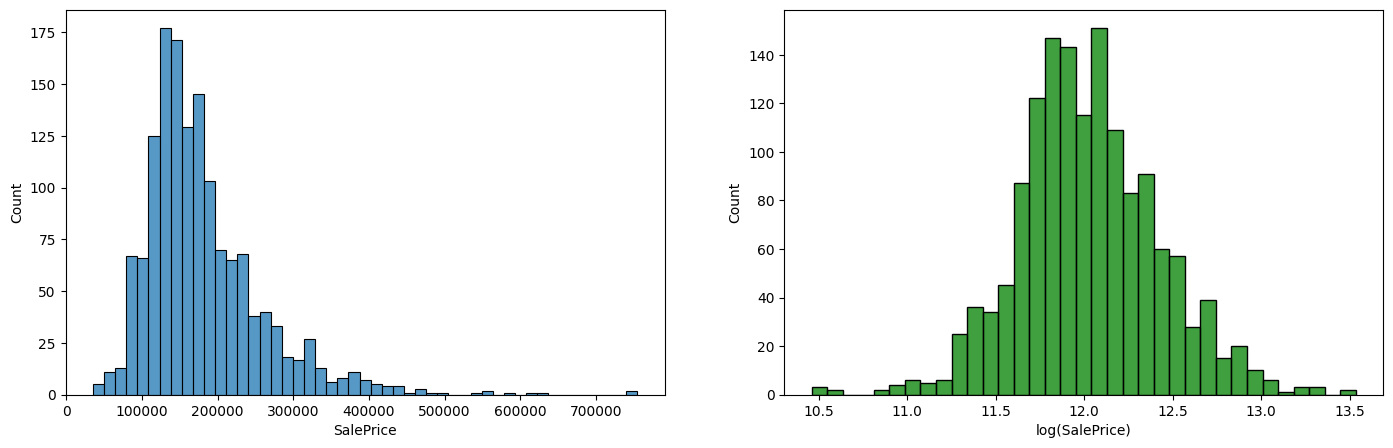

In [32]:
y_log = np.log(y)

plt.figure(figsize=(17, 5))

plt.subplot(1, 2, 1)
sns.histplot(y)

plt.subplot(1, 2, 2)
sns.histplot(y_log, color='green')

plt.xlabel("log(SalePrice)")

# Metrics: RMSLE & RMSE

In order to submit our predictions onto Kaggle, we need to code our own RMSLE. We can either code it manually, or use some of the pre-coded sklearn metrics. In both cases we will need to use the [`make_scorer`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html).

## RMSLE

RMSLE formula

$$\text{RMSLE}(y, \hat{y}) = \sqrt{\frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples} - 1} (\log_e (1 + y_i) - \log_e (1 + \hat{y}_i) )^2.}$$

In [33]:
# Method one: by hand
def root_mean_squared_log_error(y_true, y_pred):
    t = np.array(y_true)
    p = np.array(y_pred)

    log_error = np.log(1+t) - np.log(1+p)

    return ((log_error**2).mean()) ** 0.5

# This is our metric to minimize
rmsle = make_scorer(root_mean_squared_log_error)

# This is our score to maximize
rmsle_neg = make_scorer(lambda y_true, y_pred: -1 * root_mean_squared_log_error(y_true, y_pred))

In [34]:
# Method two: Using sklearn
# This is our metric to minimize
rmsle = make_scorer(lambda y_true, y_pred: mean_squared_log_error(y_true, y_pred)**0.5)

# This is our score to maximize
rmsle_neg = make_scorer(lambda y_true, y_pred: -1 * mean_squared_log_error(y_true, y_pred)**0.5)

## RMSE

Since we also have y_log, we need to be able to compute the RMSE.

In [35]:
# Create your new scorer to minimize
rmse = make_scorer(lambda y_true, y_pred: mean_squared_error(y_true, y_pred)**0.5)

# Create your new scorer to maximize
rmse_neg = make_scorer(lambda y_true, y_pred: -1 * mean_squared_error(y_true, y_pred)**0.5)

# Models

Now let's test a few models first in order to get a baseline, and see which ones are the most promising, since grid searching every single model out there would be too time consuming. Since we have a preproc pipel, we just need to add a model at the end of it and cross validate it in order to compare our different models. Our hard work earlier make this part a lot easier!

In [36]:
preproc

ColumnTransformer(transformers=[('columntransformer',
                                 ColumnTransformer(transformers=[('pipeline-1',
                                                                  Pipeline(steps=[('knnimputer',
                                                                                   KNNImputer()),
                                                                                  ('standardscaler',
                                                                                   StandardScaler())]),
                                                                  ['OverallQual',
                                                                   'OverallCond',
                                                                   'TotalBsmtSF',
                                                                   '1stFlrSF',
                                                                   'GrLivArea',
                                                                   'BedroomAbvGr',
                                                                   'TotRmsAbvGrd',
                                                                   'GarageCars',
                                                                   'GarageArea',
                                                                   'MoSold']),
                                                                 ('pipeline-2',
                                                                  Pipeline(steps=[('knni...
                                                                 dtype=<class 'numpy.int64'>,
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1)),
                                                 ('minmaxscaler',
                                                  MinMaxScaler())]),
                                 ['BsmtCond', 'BsmtExposure', 'BsmtFinType1',
                                  'BsmtFinType2', 'BsmtQual', 'Electrical',
                                  'ExterCond', 'ExterQual', 'Functional',
                                  'GarageCond', 'GarageFinish', 'GarageQual',
                                  'HeatingQC', 'KitchenQual', 'LandContour',
                                  'LandSlope', 'LotShape', 'PavedDrive'])])

## Baseline - Decision Tree

In [37]:
pipe_baseline = make_pipeline(preproc,
                             DecisionTreeRegressor())
pipe_baseline

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('columntransformer',
                                                  ColumnTransformer(transformers=[('pipeline-1',
                                                                                   Pipeline(steps=[('knnimputer',
                                                                                                    KNNImputer()),
                                                                                                   ('standardscaler',
                                                                                                    StandardScaler())]),
                                                                                   ['OverallQual',
                                                                                    'OverallCond',
                                                                                    'TotalBsmtSF',
                                                                                    '1stFlrSF',
                                                                                    'GrLivArea',
                                                                                    'BedroomAbvGr',
                                                                                    'TotRmsAbvGrd',
                                                                                    'GarageCars',
                                                                                    'GarageArea',
                                                                                    'MoSold'])...
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1)),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'BsmtQual',
                                                   'Electrical', 'ExterCond',
                                                   'ExterQual', 'Functional',
                                                   'GarageCond', 'GarageFinish',
                                                   'GarageQual', 'HeatingQC',
                                                   'KitchenQual', 'LandContour',
                                                   'LandSlope', 'LotShape',
                                                   'PavedDrive'])])),
                ('decisiontreeregressor', DecisionTreeRegressor())])

Let's compare the score using our target and the log of our target.

In [41]:
cv_baseline = cross_validate(pipe_baseline, X, y, scoring=rmsle, cv=5)
cv_baseline

{'fit_time': array([0.17311168, 0.15133357, 0.16211534, 0.15923882, 0.16395473]),
 'score_time': array([0.03778887, 0.04668427, 0.03885293, 0.06297922, 0.04857731]),
 'test_score': array([0.21631823, 0.22751402, 0.18071909, 0.20968783, 0.22788697])}

In [42]:
final_scores = {
    'model_name': [],
    'score': [],
    'log': []
}

In [43]:
final_scores['model_name'].append('baseline')
final_scores['score'].append(cv_baseline['test_score'].mean())
final_scores['log'].append(False)
final_scores

{'model_name': ['baseline'], 'score': [0.21242522895876642], 'log': [False]}

## Testing out different Regressors

In [44]:
models = [Ridge(),  # linear model
          SVR(), KNeighborsRegressor(),         # other types of models we've studied
          RandomForestRegressor(), AdaBoostRegressor(), GradientBoostingRegressor() ,   # ensemble methods
         XGBRegressor()
         ]

### RMSLE

In [45]:
for model in models:
    model_name = str(model)[:-2]
    print(f'Starting cv of model {model_name}')
    final_scores['model_name'].append(model_name)

    pipe = make_pipeline(preproc, model)
    cv_res = cross_validate(pipe, X, y, scoring=rmsle, cv=5)

    final_scores['score'].append(cv_res['test_score'].mean())

    final_scores['log'].append(False)

Starting cv of model Ridge
Starting cv of model SVR
Starting cv of model KNeighborsRegressor
Starting cv of model RandomForestRegressor
Starting cv of model AdaBoostRegressor
Starting cv of model GradientBoostingRegressor
Starting cv of model XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, gamma=None,
             gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, predictor=None, random_state=None,
             reg_alpha=None, reg_lambda=None, ..


In [46]:
final_scores

{'model_name': ['baseline',
  'Ridge',
  'SVR',
  'KNeighborsRegressor',
  'RandomForestRegressor',
  'AdaBoostRegressor',
  'GradientBoostingRegressor',
  'XGBRegressor(base_score=None, booster=None, callbacks=None,\n             colsample_bylevel=None, colsample_bynode=None,\n             colsample_bytree=None, early_stopping_rounds=None,\n             enable_categorical=False, eval_metric=None, gamma=None,\n             gpu_id=None, grow_policy=None, importance_type=None,\n             interaction_constraints=None, learning_rate=None, max_bin=None,\n             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,\n             max_leaves=None, min_child_weight=None, missing=nan,\n             monotone_constraints=None, n_estimators=100, n_jobs=None,\n             num_parallel_tree=None, predictor=None, random_state=None,\n             reg_alpha=None, reg_lambda=None, ..'],
 'score': [0.21242522895876642,
  0.19141159385302597,
  0.39968150833756,
  0.25212226134043875,
  0.

In [47]:
pd.DataFrame(final_scores, columns=['model_name', 'score', 'log']).sort_values(by='score')

,model_name,score,log
6,GradientBoostingRegressor,0.129080,False
7,"XGBRegressor(base_score=None, booster=None, ca...",0.135464,False
4,RandomForestRegressor,0.145006,False
1,Ridge,0.191412,False
5,AdaBoostRegressor,0.201532,False
0,baseline,0.212425,False
3,KNeighborsRegressor,0.252122,False
2,SVR,0.399682,False


We can see that our gradient boost is by far the best. Let's try fine tuning our top three models.

**PS:** If we used a simple linear regression, we might end up with some negative values and an error message, along the lines of: 
*ValueError: Mean Squared Logarithmic Error cannot be used when targets contain negative values.*
A fix would be to use a Min max scaler, which would set the values between 0 and 1 and force our values to never go below zero..!

### RMSE

Let's see if we can a different score when using the log of our target

In [48]:
for model in models:
    model_name = str(model)[:-2]
    print(f'Starting cv of model {model_name}')
    final_scores['model_name'].append(model_name)

    pipe = make_pipeline(preproc, model)
    cv_res = cross_validate(pipe, X, y_log, scoring=rmse, cv=5)

    final_scores['score'].append(cv_res['test_score'].mean())

    final_scores['log'].append(True)

Starting cv of model Ridge
Starting cv of model SVR
Starting cv of model KNeighborsRegressor
Starting cv of model RandomForestRegressor
Starting cv of model AdaBoostRegressor
Starting cv of model GradientBoostingRegressor
Starting cv of model XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, gamma=None,
             gpu_id=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, predictor=None, random_state=None,
             reg_alpha=None, reg_lambda=None, ..


In [49]:
pd.DataFrame(final_scores, columns=['model_name','score', 'log']).sort_values(by='score')

,model_name,score,log
13,GradientBoostingRegressor,0.125759,True
6,GradientBoostingRegressor,0.129080,False
7,"XGBRegressor(base_score=None, booster=None, ca...",0.135464,False
14,"XGBRegressor(base_score=None, booster=None, ca...",0.137204,True
8,Ridge,0.140184,True
11,RandomForestRegressor,0.142372,True
4,RandomForestRegressor,0.145006,False
12,AdaBoostRegressor,0.174272,True
1,Ridge,0.191412,False
5,AdaBoostRegressor,0.201532,False


All of our scores have improved! let's try submitting our gradient boost predictions to Kaggle. 

# Initial Submission

Since we're going to be submitting a few scores to Kaggle, let's code a function that, given a pipe, creates a csv with our predictions that has the right format.

In [50]:
def pred_to_csv(estimator, name):
    X_test = pd.read_csv("https://wagon-public-datasets.s3.amazonaws.com/houses_test_raw.csv")
    X_test_ids = X_test['Id']
    X_test = X_test.drop(columns=['Id'])
    estimator.fit(X,y)
    y_pred_baseline = estimator.predict(X_test)
    predictions = pd.concat([X_test_ids, pd.Series(y_pred_baseline, name="SalePrice")], axis=1)
    predictions.to_csv(f"{name}.csv", header=True, index=False)

We saw that our predictions with the log of y seemed to work better. However, we have to change our predictions back to the right scale before submitting them!

In [51]:
def pred_to_csv_ylog(estimator, name):
    X_test = pd.read_csv("https://wagon-public-datasets.s3.amazonaws.com/houses_test_raw.csv")
    X_test_ids = X_test['Id']
    X_test = X_test.drop(columns=['Id'])
    estimator.fit(X,y_log)
    y_pred_log = estimator.predict(X_test)
    y_pred = np.exp(y_pred_log)
    predictions = pd.concat([X_test_ids, pd.Series(y_pred, name="SalePrice")], axis=1)
    predictions.to_csv(f"{name}.csv", header=True, index=False)

In [52]:
pipe_grad = make_pipeline(preproc, GradientBoostingRegressor())
pipe_grad

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('columntransformer',
                                                  ColumnTransformer(transformers=[('pipeline-1',
                                                                                   Pipeline(steps=[('knnimputer',
                                                                                                    KNNImputer()),
                                                                                                   ('standardscaler',
                                                                                                    StandardScaler())]),
                                                                                   ['OverallQual',
                                                                                    'OverallCond',
                                                                                    'TotalBsmtSF',
                                                                                    '1stFlrSF',
                                                                                    'GrLivArea',
                                                                                    'BedroomAbvGr',
                                                                                    'TotRmsAbvGrd',
                                                                                    'GarageCars',
                                                                                    'GarageArea',
                                                                                    'MoSold'])...
                                                                                  unknown_value=-1)),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['BsmtCond', 'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'BsmtQual',
                                                   'Electrical', 'ExterCond',
                                                   'ExterQual', 'Functional',
                                                   'GarageCond', 'GarageFinish',
                                                   'GarageQual', 'HeatingQC',
                                                   'KitchenQual', 'LandContour',
                                                   'LandSlope', 'LotShape',
                                                   'PavedDrive'])])),
                ('gradientboostingregressor', GradientBoostingRegressor())])

In [53]:
pred_to_csv_ylog(pipe_grad, 'advanced_grad_no_grid')

We got a score of **0.133** on Kaggle, compared to around **0.125** on our train set. 

In [54]:
pipe_boost = make_pipeline(preproc, XGBRegressor())
pipe_boost

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('columntransformer',
                                                  ColumnTransformer(transformers=[('pipeline-1',
                                                                                   Pipeline(steps=[('knnimputer',
                                                                                                    KNNImputer()),
                                                                                                   ('standardscaler',
                                                                                                    StandardScaler())]),
                                                                                   ['OverallQual',
                                                                                    'OverallCond',
                                                                                    'TotalBsmtSF',
                                                                                    '1stFlrSF',
                                                                                    'GrLivArea',
                                                                                    'BedroomAbvGr',
                                                                                    'TotRmsAbvGrd',
                                                                                    'GarageCars',
                                                                                    'GarageArea',
                                                                                    'MoSold'])...
                              gamma=None, gpu_id=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_to_onehot=None,
                              max_delta_step=None, max_depth=None,
                              max_leaves=None, min_child_weight=None,
                              missing=nan, monotone_constraints=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, predictor=None,
                              random_state=None, reg_alpha=None,
                              reg_lambda=None, ...))])

In [55]:
pred_to_csv_ylog(pipe_boost, 'advanced_boost_no_grid')

Now let's fine tune both models.

# Fine Tuning

In [56]:
pipe_grad.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('columntransformer',
                                    ColumnTransformer(transformers=[('pipeline-1',
                                                                     Pipeline(steps=[('knnimputer',
                                                                                      KNNImputer()),
                                                                                     ('standardscaler',
                                                                                      StandardScaler())]),
                                                                     ['OverallQual',
                                                                      'OverallCond',
                                                                      'TotalBsmtSF',
                                                                      '1stFlrSF',
                                                             

In [57]:
param_grid =  {'gradientboostingregressor__alpha': stats.uniform(0.001, 1),
              'gradientboostingregressor__learning_rate': stats.uniform(0.0001, 1),
              'gradientboostingregressor__max_depth': stats.randint(3, 10),
               'gradientboostingregressor__min_samples_leaf': stats.randint(3, 10),
               'gradientboostingregressor__n_estimators': stats.randint(50, 300)
              }


search_grad = RandomizedSearchCV(
        pipe_grad,
        param_grid,
        cv=5,
        n_iter=100,
        n_jobs=-1,
        verbose=2,
        scoring=rmse_neg
    )

search_grad.fit(X, y_log)
search_grad.best_score_, search_grad.best_params_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END gradientboostingregressor__alpha=0.044254064527489256, gradientboostingregressor__learning_rate=0.2430741986309608, gradientboostingregressor__max_depth=3, gradientboostingregressor__min_samples_leaf=7, gradientboostingregressor__n_estimators=108; total time=   1.9s
[CV] END gradientboostingregressor__alpha=0.14875106135208183, gradientboostingregressor__learning_rate=0.2877176250171031, gradientboostingregressor__max_depth=5, gradientboostingregressor__min_samples_leaf=9, gradientboostingregressor__n_estimators=199; total time=   5.1s
[CV] END gradientboostingregressor__alpha=0.1424561059832855, gradientboostingregressor__learning_rate=0.6274465449905329, gradientboostingregressor__max_depth=3, gradientboostingregressor__min_samples_leaf=9, gradientboostingregressor__n_estimators=163; total time=   2.8s
[CV] END gradientboostingregressor__alpha=0.9846162068262625, gradientboostingregressor__learning_rate=0.3478879

[CV] END gradientboostingregressor__alpha=0.905886637829387, gradientboostingregressor__learning_rate=0.1930365920199265, gradientboostingregressor__max_depth=3, gradientboostingregressor__min_samples_leaf=8, gradientboostingregressor__n_estimators=94; total time=   2.0s
[CV] END gradientboostingregressor__alpha=0.14875106135208183, gradientboostingregressor__learning_rate=0.2877176250171031, gradientboostingregressor__max_depth=5, gradientboostingregressor__min_samples_leaf=9, gradientboostingregressor__n_estimators=199; total time=   5.9s
[CV] END gradientboostingregressor__alpha=0.34321147684510345, gradientboostingregressor__learning_rate=0.4097337104959353, gradientboostingregressor__max_depth=4, gradientboostingregressor__min_samples_leaf=4, gradientboostingregressor__n_estimators=233; total time=   5.8s
[CV] END gradientboostingregressor__alpha=0.29625012768262793, gradientboostingregressor__learning_rate=0.5270172633244099, gradientboostingregressor__max_depth=5, gradientboosti

[CV] END gradientboostingregressor__alpha=0.905886637829387, gradientboostingregressor__learning_rate=0.1930365920199265, gradientboostingregressor__max_depth=3, gradientboostingregressor__min_samples_leaf=8, gradientboostingregressor__n_estimators=94; total time=   2.0s
[CV] END gradientboostingregressor__alpha=0.14875106135208183, gradientboostingregressor__learning_rate=0.2877176250171031, gradientboostingregressor__max_depth=5, gradientboostingregressor__min_samples_leaf=9, gradientboostingregressor__n_estimators=199; total time=   5.8s
[CV] END gradientboostingregressor__alpha=0.34321147684510345, gradientboostingregressor__learning_rate=0.4097337104959353, gradientboostingregressor__max_depth=4, gradientboostingregressor__min_samples_leaf=4, gradientboostingregressor__n_estimators=233; total time=   5.9s
[CV] END gradientboostingregressor__alpha=0.29625012768262793, gradientboostingregressor__learning_rate=0.5270172633244099, gradientboostingregressor__max_depth=5, gradientboosti

[CV] END gradientboostingregressor__alpha=0.7411728025801125, gradientboostingregressor__learning_rate=0.852396435971398, gradientboostingregressor__max_depth=8, gradientboostingregressor__min_samples_leaf=8, gradientboostingregressor__n_estimators=279; total time=  10.3s
[CV] END gradientboostingregressor__alpha=0.34695123626610214, gradientboostingregressor__learning_rate=0.3358184840159606, gradientboostingregressor__max_depth=3, gradientboostingregressor__min_samples_leaf=7, gradientboostingregressor__n_estimators=165; total time=   2.8s
[CV] END gradientboostingregressor__alpha=0.9114971895645932, gradientboostingregressor__learning_rate=0.8406374592594374, gradientboostingregressor__max_depth=7, gradientboostingregressor__min_samples_leaf=6, gradientboostingregressor__n_estimators=115; total time=   4.1s
[CV] END gradientboostingregressor__alpha=0.3483833964099581, gradientboostingregressor__learning_rate=0.6731671533774377, gradientboostingregressor__max_depth=5, gradientboostin

[CV] END gradientboostingregressor__alpha=0.905886637829387, gradientboostingregressor__learning_rate=0.1930365920199265, gradientboostingregressor__max_depth=3, gradientboostingregressor__min_samples_leaf=8, gradientboostingregressor__n_estimators=94; total time=   1.9s
[CV] END gradientboostingregressor__alpha=0.14875106135208183, gradientboostingregressor__learning_rate=0.2877176250171031, gradientboostingregressor__max_depth=5, gradientboostingregressor__min_samples_leaf=9, gradientboostingregressor__n_estimators=199; total time=   5.8s
[CV] END gradientboostingregressor__alpha=0.34321147684510345, gradientboostingregressor__learning_rate=0.4097337104959353, gradientboostingregressor__max_depth=4, gradientboostingregressor__min_samples_leaf=4, gradientboostingregressor__n_estimators=233; total time=   5.8s
[CV] END gradientboostingregressor__alpha=0.9114971895645932, gradientboostingregressor__learning_rate=0.8406374592594374, gradientboostingregressor__max_depth=7, gradientboostin

[CV] END gradientboostingregressor__alpha=0.7411728025801125, gradientboostingregressor__learning_rate=0.852396435971398, gradientboostingregressor__max_depth=8, gradientboostingregressor__min_samples_leaf=8, gradientboostingregressor__n_estimators=279; total time=  12.0s
[CV] END gradientboostingregressor__alpha=0.34695123626610214, gradientboostingregressor__learning_rate=0.3358184840159606, gradientboostingregressor__max_depth=3, gradientboostingregressor__min_samples_leaf=7, gradientboostingregressor__n_estimators=165; total time=   3.5s
[CV] END gradientboostingregressor__alpha=0.3483833964099581, gradientboostingregressor__learning_rate=0.6731671533774377, gradientboostingregressor__max_depth=5, gradientboostingregressor__min_samples_leaf=5, gradientboostingregressor__n_estimators=262; total time=   7.7s
[CV] END gradientboostingregressor__alpha=0.3793038400116754, gradientboostingregressor__learning_rate=0.44250100807266146, gradientboostingregressor__max_depth=8, gradientboosti

(-0.12498834839687203,
 {'gradientboostingregressor__alpha': 0.5272048463194969,
  'gradientboostingregressor__learning_rate': 0.06536803416945237,
  'gradientboostingregressor__max_depth': 4,
  'gradientboostingregressor__min_samples_leaf': 3,
  'gradientboostingregressor__n_estimators': 137})

In [64]:
final_scores['model_name'].append('GradBoost+Grid')
final_scores['score'].append(np.abs(search_grad.best_score_))
final_scores['log'].append(True)

In [65]:
pd.DataFrame(final_scores, columns=['model_name', 'score', 'log']).sort_values(by='score')

,model_name,score,log
15,GradBoost+Grid,-0.124988,True
16,GradBoost+Grid,0.124988,True
13,GradientBoostingRegressor,0.125759,True
6,GradientBoostingRegressor,0.129080,False
7,"XGBRegressor(base_score=None, booster=None, ca...",0.135464,False
14,"XGBRegressor(base_score=None, booster=None, ca...",0.137204,True
8,Ridge,0.140184,True
11,RandomForestRegressor,0.142372,True
4,RandomForestRegressor,0.145006,False
12,AdaBoostRegressor,0.174272,True


In [66]:
best_grad = search_grad.best_estimator_

In [67]:
pred_to_csv_ylog(best_grad, 'advanced_grad_grid')

With the grid search, we went from **0.133** to **0.129** on Kaggle.

In [68]:
pipe_boost.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('columntransformer',
                                    ColumnTransformer(transformers=[('pipeline-1',
                                                                     Pipeline(steps=[('knnimputer',
                                                                                      KNNImputer()),
                                                                                     ('standardscaler',
                                                                                      StandardScaler())]),
                                                                     ['OverallQual',
                                                                      'OverallCond',
                                                                      'TotalBsmtSF',
                                                                      '1stFlrSF',
                                                             

In [69]:
param_grid =  {'xgbregressor__reg_alpha': stats.uniform(0.001, 0.5),
              'xgbregressor__learning_rate': stats.uniform(0.0001, 1),
              'xgbregressor__max_depth': stats.randint(3, 10),
               'xgbregressor__n_estimators': stats.randint(50, 400),
               'xgbregressor__gamma': stats.uniform(0, 0.3)
              }


search_boost = RandomizedSearchCV(
        pipe_boost,
        param_grid,
        cv=5,
        n_iter=50,
        n_jobs=-1,
        verbose=1,
        scoring=rmse_neg
    )

search_boost.fit(X, y_log)
search_boost.best_score_, search_boost.best_params_

Fitting 5 folds for each of 50 candidates, totalling 250 fits


(-0.12937281579324378,
 {'xgbregressor__gamma': 0.012164726390920932,
  'xgbregressor__learning_rate': 0.15464334631760734,
  'xgbregressor__max_depth': 9,
  'xgbregressor__n_estimators': 183,
  'xgbregressor__reg_alpha': 0.125713949954267})

In [70]:
final_scores['model_name'].append('XGBoost+Grid')
final_scores['score'].append(np.abs(search_boost.best_score_))
final_scores['log'].append(True)

In [71]:
pd.DataFrame(final_scores, columns=['model_name', 'score', 'log']).sort_values(by='score')

,model_name,score,log
15,GradBoost+Grid,-0.124988,True
16,GradBoost+Grid,0.124988,True
13,GradientBoostingRegressor,0.125759,True
6,GradientBoostingRegressor,0.129080,False
17,XGBoost+Grid,0.129373,True
7,"XGBRegressor(base_score=None, booster=None, ca...",0.135464,False
14,"XGBRegressor(base_score=None, booster=None, ca...",0.137204,True
8,Ridge,0.140184,True
11,RandomForestRegressor,0.142372,True
4,RandomForestRegressor,0.145006,False


In [72]:
pred_to_csv_ylog(search_boost.best_estimator_, 'advanced_boost_grid')

This also gives us a score of around **.129** on Kaggle.

# Stacking

Since we're working on ensemble methods, let's try stacking a few models to see if they fare any better as a group than on their own. Let's first stack models that are very different in the hopes that they'll capture different aspects of our data. 

In [73]:
gboost = GradientBoostingRegressor(n_estimators=100)
ridge = Ridge()
svm = SVR(C=1, epsilon=0.05)
knn = KNeighborsRegressor()
xgb = XGBRegressor()

model = StackingRegressor(
    estimators=[("gboost", gboost), ("ridge", ridge), ("svm_rbf", svm), ('knn', knn), ('xgboost', xgb)],
    final_estimator=LinearRegression(),
    cv=5,
    n_jobs=-1
)

pipe_stack = make_pipeline(preproc, model)
cv = cross_validate(pipe_stack, X, y_log, cv=5, scoring=rmse)
cv['test_score'].mean()

0.12315749770662662

In [74]:
final_scores['model_name'].append('Stack5')
final_scores['score'].append(cv['test_score'].mean())
final_scores['log'].append(True)

In [75]:
pred_to_csv_ylog(pipe_stack, 'advanced_stack_no_grid')

This model generalized the best. We went from **0.123** to **0.126** on Kaggle. We could try adding more models, or grid searching this to see if we get a better score.

In [76]:
pipe_stack.get_params()

{'memory': None,
 'steps': [('columntransformer',
   ColumnTransformer(transformers=[('columntransformer',
                                    ColumnTransformer(transformers=[('pipeline-1',
                                                                     Pipeline(steps=[('knnimputer',
                                                                                      KNNImputer()),
                                                                                     ('standardscaler',
                                                                                      StandardScaler())]),
                                                                     ['OverallQual',
                                                                      'OverallCond',
                                                                      'TotalBsmtSF',
                                                                      '1stFlrSF',
                                                             

This cell takes a *long* time to run, you would usually set the iterations to a higher number and just let it run during your lunch break...

In [77]:
param_grid =  {'stackingregressor__gboost__alpha': stats.uniform(0.001, 0.5),
              'stackingregressor__gboost__learning_rate': stats.uniform(0.0001, 1),
              'stackingregressor__gboost__max_depth': stats.randint(3, 10),
               'stackingregressor__gboost__n_estimators': stats.randint(50, 400),
               'stackingregressor__ridge__alpha': stats.uniform(0.001, 0.5),
               'stackingregressor__svm_rbf__C': stats.uniform(0.001, 10),
               'stackingregressor__knn__n_neighbors': stats.randint(5, 30),
               'stackingregressor__xgboost__reg_alpha': stats.uniform(0, 0.3),
               'stackingregressor__xgboost__learning_rate': stats.uniform(0.0001, 1),
               'stackingregressor__xgboost__max_depth': stats.randint(3, 10),
               'stackingregressor__xgboost__n_estimators': stats.randint(50, 400)
              }


search_stack = RandomizedSearchCV(
        pipe_stack,
        param_grid,
        cv=5,
        n_iter=25,
        n_jobs=-1,
        verbose=1,
        scoring=rmse_neg
    )

search_stack.fit(X, y_log)
search_stack.best_score_, search_stack.best_params_

Fitting 5 folds for each of 25 candidates, totalling 125 fits


(-0.12088039204789455,
 {'stackingregressor__gboost__alpha': 0.2002660480576483,
  'stackingregressor__gboost__learning_rate': 0.11199895986582599,
  'stackingregressor__gboost__max_depth': 4,
  'stackingregressor__gboost__n_estimators': 101,
  'stackingregressor__knn__n_neighbors': 17,
  'stackingregressor__ridge__alpha': 0.27469030194858446,
  'stackingregressor__svm_rbf__C': 1.3089435801344873,
  'stackingregressor__xgboost__learning_rate': 0.05091258972866043,
  'stackingregressor__xgboost__max_depth': 5,
  'stackingregressor__xgboost__n_estimators': 89,
  'stackingregressor__xgboost__reg_alpha': 0.12309946030073338})

In [78]:
search_stack.best_score_, search_stack.best_params_

(-0.12088039204789455,
 {'stackingregressor__gboost__alpha': 0.2002660480576483,
  'stackingregressor__gboost__learning_rate': 0.11199895986582599,
  'stackingregressor__gboost__max_depth': 4,
  'stackingregressor__gboost__n_estimators': 101,
  'stackingregressor__knn__n_neighbors': 17,
  'stackingregressor__ridge__alpha': 0.27469030194858446,
  'stackingregressor__svm_rbf__C': 1.3089435801344873,
  'stackingregressor__xgboost__learning_rate': 0.05091258972866043,
  'stackingregressor__xgboost__max_depth': 5,
  'stackingregressor__xgboost__n_estimators': 89,
  'stackingregressor__xgboost__reg_alpha': 0.12309946030073338})

In [79]:
final_scores['model_name'].append('Stack5+Grid')
final_scores['score'].append(np.abs(search_stack.best_score_))
final_scores['log'].append(True)

In [85]:
pd.DataFrame(final_scores, columns=['model_name', 'score', 'log']).sort_values(by='score')[1:]

,model_name,score,log
19,Stack5,0.120880,True
18,Stack5,0.123157,True
16,GradBoost+Grid,0.124988,True
13,GradientBoostingRegressor,0.125759,True
6,GradientBoostingRegressor,0.129080,False
17,XGBoost+Grid,0.129373,True
7,"XGBRegressor(base_score=None, booster=None, ca...",0.135464,False
14,"XGBRegressor(base_score=None, booster=None, ca...",0.137204,True
8,Ridge,0.140184,True
11,RandomForestRegressor,0.142372,True


In [86]:
pred_to_csv_ylog(search_stack.best_estimator_, 'advanced_stack_grid')

# Bonus Section: Other libraries 

There are some other boosting algorithms that aren't available on Sklearn but are nonetheless pretty great. 

[LightGBM](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html) tends to perform even better than XGBoost, but it's not always compatible with Sklearn. Same with [CatBoost](https://catboost.ai/en/docs/concepts/python-reference_catboostregressor). (You will need to pip install both libraries if you want to experiment with them). Most of the top scorers for the competition use either one or the other, if not both.

I recommend reading [this article](https://machinelearningmastery.com/gradient-boosting-with-scikit-learn-xgboost-lightgbm-and-catboost/), which has examples on how to use all of them.

## Light GBM

In [87]:
from lightgbm import LGBMRegressor

In [91]:
model = LGBMRegressor()
pipe_lgbm = make_pipeline(preproc, model)
cv_lgbm = cross_validate(pipe_lgbm, X, y_log, cv=5, scoring=rmse)
cv_lgbm

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000921 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3167
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 131
[LightGBM] [Info] Start training from score 12.021402
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000756 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3179
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 128
[LightGBM] [Info] Start training from score 12.023281
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002445 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3174
[LightGBM] [Info] Number of data points in the train s

{'fit_time': array([0.30164027, 0.28661704, 0.29279995, 0.29505658, 0.28327036]),
 'score_time': array([0.03297019, 0.03771377, 0.03724813, 0.06156754, 0.03864026]),
 'test_score': array([0.12007946, 0.14317561, 0.13712732, 0.11538638, 0.13333693])}

In [92]:
final_scores['model_name'].append('LGBM')
final_scores['score'].append(cv_lgbm['test_score'].mean())
final_scores['log'].append(True)

In [93]:
pd.DataFrame(final_scores, columns=['model_name', 'score', 'log']).sort_values(by='score')[1:]

,model_name,score,log
19,Stack5,0.120880,True
18,Stack5,0.123157,True
16,GradBoost+Grid,0.124988,True
13,GradientBoostingRegressor,0.125759,True
6,GradientBoostingRegressor,0.129080,False
17,XGBoost+Grid,0.129373,True
20,LGBM,0.129821,True
7,"XGBRegressor(base_score=None, booster=None, ca...",0.135464,False
14,"XGBRegressor(base_score=None, booster=None, ca...",0.137204,True
8,Ridge,0.140184,True


## Bayesian Ridge

In [94]:
from sklearn.linear_model import BayesianRidge

In [96]:
pipe = make_pipeline(preproc, BayesianRidge())
cv_bayes = cross_validate(pipe, X, y_log, cv=5, scoring=rmse)['test_score'].mean()
cv_bayes

0.1383433995233286

In [97]:
final_scores['model_name'].append('bayesian ridge')
final_scores['score'].append(cv_bayes)
final_scores['log'].append(True)

In [98]:
pd.DataFrame(final_scores, columns=['model_name', 'score', 'log']).sort_values(by='score')[1:]

,model_name,score,log
19,Stack5,0.120880,True
18,Stack5,0.123157,True
16,GradBoost+Grid,0.124988,True
13,GradientBoostingRegressor,0.125759,True
6,GradientBoostingRegressor,0.129080,False
17,XGBoost+Grid,0.129373,True
20,LGBM,0.129821,True
7,"XGBRegressor(base_score=None, booster=None, ca...",0.135464,False
14,"XGBRegressor(base_score=None, booster=None, ca...",0.137204,True
21,bayesian ridge,0.138343,True
